In [1]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')
df.columns

Index(['inventory_year', 'survey_unit', 'county', 'plot_number', 'tree_number',
       'diameter', 'height', 'SPCD', 'log_height', 'log_diameter'],
      dtype='str')

To see if our hierarchical structure actually improves our predictions, let's fit a simple, 'naive' model. This baseline model completely ignores regional differences (counties) and assumes all trees follow one universal growth trend


In [2]:
model_formula = "log_height ~ log_diameter"

model = bmb.Model(model_formula, df)

In [3]:
results = model.fit(draws=2000, tune=2000)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


In [4]:
az.summary(results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,0.222,0.009,0.206,0.238,0.0,0.000,11686.0,5950.0,1.0
Intercept,0.175,0.047,0.087,0.264,0.0,0.001,11813.0,6147.0,1.0
log_diameter,0.800,0.017,0.769,0.832,0.0,0.000,11772.0,6456.0,1.0


In [5]:
model

       Formula: log_height ~ log_diameter
        Family: gaussian
          Link: mu = identity
  Observations: 344
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 2.3727, sigma: 6.0911)
            log_diameter ~ Normal(mu: 0.0, sigma: 2.1495)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 0.6046)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

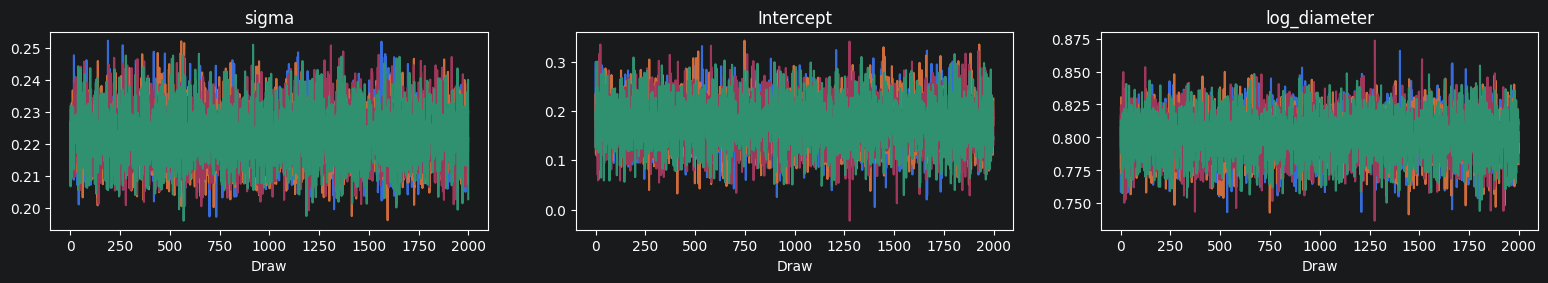

In [6]:
azp.plot_trace(results)

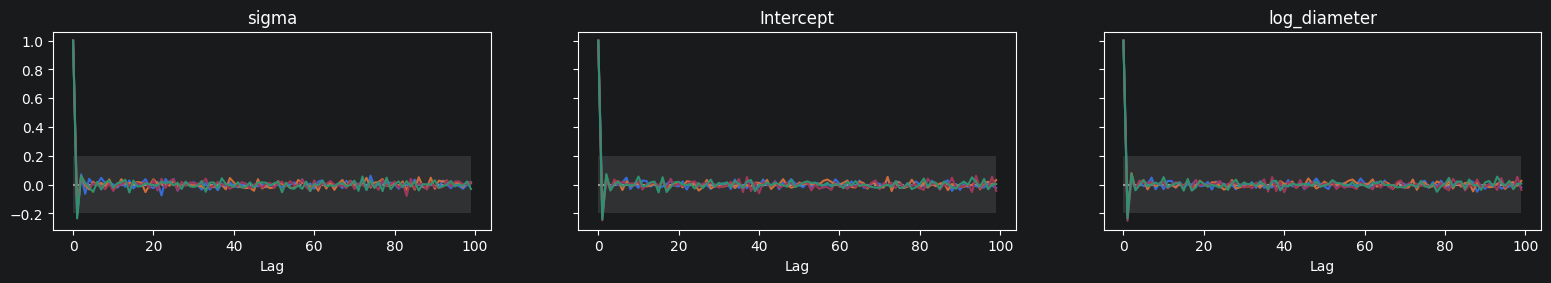

In [7]:
azp.plot_autocorr(results)

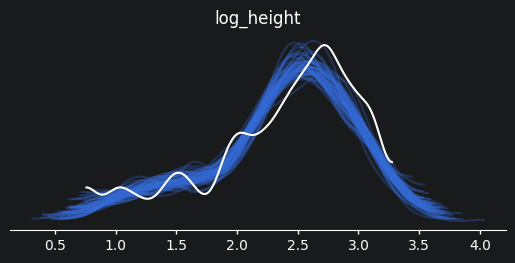

In [8]:
model.predict(results, kind="response")
azp.plot_ppc_dist(results)